# PyTorch GPU 및 데이터로더(DataLoader) 검증

이 노트북은 프로젝트 폴더 내 식물 병해 데이터셋(`New Plant Diseases Dataset(Augmented)`)을 로드하고, PC 그래픽카드(CUDA)를 사용해 간단한 텐서 연산이 정상 동작하는지 테스트합니다.

In [1]:
import os
import torch
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")

PyTorch Version: 2.12.0+cu126
Torchvision Version: 0.27.0+cu126


## 1. 그래픽카드 (GPU) 연산 검증

CUDA 사용 가능 여부를 확인하고, GPU 상에서 간단한 텐서 행렬 곱셈 연산을 수행하여 작동 여부 및 연산 시간을 측정합니다.

In [2]:
cuda_available = torch.cuda.is_available()
print(f"CUDA Available: {cuda_available}")

if cuda_available:
    device = torch.device("cuda")
    device_name = torch.cuda.get_device_name(0)
    print(f"Using GPU: {device_name}")
    
    # GPU 상에서 무작위 텐서 생성
    x = torch.randn(2000, 2000, device=device)
    y = torch.randn(2000, 2000, device=device)
    
    # 연산 시간 측정을 위한 CUDA Event 생성
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    
    start_event.record()
    # 행렬 곱 연산 수행
    z = torch.matmul(x, y)
    end_event.record()
    
    torch.cuda.synchronize()  # GPU 연산이 끝날 때까지 대기
    elapsed_time = start_event.elapsed_time(end_event)
    
    print("\n[GPU Verification Success]")
    print(f"Result tensor shape: {z.shape}")
    print(f"Calculation time (2000x2000 matrix multiplication): {elapsed_time:.3f} ms")
else:
    device = torch.device("cpu")
    print("\n[Warning] CUDA (GPU) is not available. Using CPU.")
    
    x = torch.randn(2000, 2000, device=device)
    y = torch.randn(2000, 2000, device=device)
    z = torch.matmul(x, y)
    print("[CPU Verification Success]")
    print(f"Result tensor shape: {z.shape}")

CUDA Available: True
Using GPU: NVIDIA GeForce RTX 3080

[GPU Verification Success]
Result tensor shape: torch.Size([2000, 2000])
Calculation time (2000x2000 matrix multiplication): 141.705 ms


## 2. 데이터셋 경로 설정 및 전처리(Transform) 정의

학습용(`train`) 및 검증용(`valid`) 이미지 데이터를 로드하고 학습에 필요한 변환(Resize, Augment, Normalization)을 적용합니다.

In [3]:
# 프로젝트 내 데이터셋 경로 설정 (절대경로)
base_dir = r"c:\Users\dltjr\Desktop\project\New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)"
train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")

print(f"Train directory exists: {os.path.exists(train_dir)}")
print(f"Valid directory exists: {os.path.exists(valid_dir)}")

# PyTorch 데이터 변환 (Transforms)
# 학습 데이터는 RandomHorizontalFlip을 추가하여 과적합을 방지하고, 검증 데이터는 단순 변환만 진행합니다.
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),       # ResNet 등의 기본 입력 크기인 224x224로 크기 조정
        transforms.RandomHorizontalFlip(),   # 데이터 증강(Data Augmentation)
        transforms.ToTensor(),              # 이미지를 PyTorch 텐서로 변환 (0~1 범위)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]) # ImageNet 표준 정규화
    ]),
    'valid': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

# ImageFolder를 통한 데이터셋 로딩
train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
valid_dataset = datasets.ImageFolder(valid_dir, transform=data_transforms['valid'])

print(f"\n[Dataset Statistics]")
print(f"Number of training samples: {len(train_dataset)}")
print(f"Number of validation samples: {len(valid_dataset)}")
print(f"Total classes: {len(train_dataset.classes)}")
print(f"Sample classes: {train_dataset.classes[:5]}")

Train directory exists: True
Valid directory exists: True

[Dataset Statistics]
Number of training samples: 70295
Number of validation samples: 17572
Total classes: 38
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## 3. 파이토치 데이터로더 (DataLoader) 생성

배치 사이즈(Batch Size)를 지정하고 데이터셋을 병렬로 로드할 수 있도록 DataLoader를 선언합니다.
Windows 환경에서는 병렬 처리를 위해 `num_workers`를 너무 높게 잡으면 에러가 발생하는 경우가 많으므로 `0` 또는 `2` 수준에서 시작하는 것이 안전합니다.

In [4]:
BATCH_SIZE = 32
NUM_WORKERS = 0 # Windows 환경의 안정성을 위해 우선 0으로 설정 (필요시 2 등으로 조정 가능)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"DataLoader successfully created!")
print(f"Train mini-batches count: {len(train_loader)}")
print(f"Valid mini-batches count: {len(valid_loader)}")

DataLoader successfully created!
Train mini-batches count: 2197
Valid mini-batches count: 550


## 4. 데이터로드 검증 및 이미지 시각화

데이터로더에서 배치를 1개 추출하여 텐서 크기를 분석하고, 정규화된 이미지를 역정규화하여 화면에 출력합니다.

Images Batch Shape: torch.Size([32, 3, 224, 224])
Labels Batch Shape: torch.Size([32])


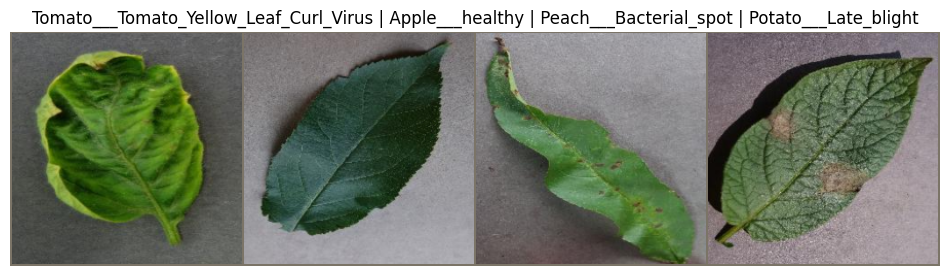

In [5]:
# 1개 배치 추출
images, labels = next(iter(train_loader))
print(f"Images Batch Shape: {images.shape}") # [BatchSize, Channels, Height, Width]
print(f"Labels Batch Shape: {labels.shape}")

# 이미지 역정규화 및 출력을 위한 헬퍼 함수
def imshow(img, title=None):
    # ImageNet 정규화 해제 (std * x + mean)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # PyTorch 텐서 [C, H, W] -> NumPy 배열 [H, W, C] 변환
    npimg = img.numpy().transpose((1, 2, 0))
    npimg = std * npimg + mean
    npimg = np.clip(npimg, 0, 1) # [0, 1] 구간으로 값 제한
    
    plt.figure(figsize=(12, 6))
    plt.imshow(npimg)
    if title is not None:
        plt.title(title, fontsize=12)
    plt.axis('off')
    plt.show()

# 처음 4개 이미지에 대한 그리드 생성
grid_img = torchvision.utils.make_grid(images[:4], nrow=4)
grid_labels = [train_dataset.classes[lbl] for lbl in labels[:4]]

# 시각화
imshow(grid_img, title=" | ".join(grid_labels))